# Avaliação e interpretabilidade do modelo

Este notebook atende ao item C: carrega o artefato persistido, reproduz a partição de teste configurada, calcula as métricas e analisa os coeficientes da regressão logística.

In [1]:
import json
from pathlib import Path

import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score,
    classification_report, precision_recall_curve,
    roc_auc_score, roc_curve,
)
from sklearn.model_selection import train_test_split

## 1. Configuração, ABT e artefato

In [2]:
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
DATA_PLATFORM_DIR = next(path for path in candidates if (path / 'Model/config_model.json').is_file())
config = json.loads((DATA_PLATFORM_DIR / 'Model/config_model.json').read_text(encoding='utf-8'))
abt_path = DATA_PLATFORM_DIR / config['metadata']['training_dataset']
artifact_path = DATA_PLATFORM_DIR / config['metadata']['artifact']
with artifact_path.open('rb') as file:
    artifact = pickle.load(file)
df = pd.read_csv(abt_path)
print(f'ABT: {df.shape[0]:,} linhas × {df.shape[1]} colunas')
print(f'Artefato: {artifact_path}')

ABT: 307,511 linhas × 34 colunas
Artefato: /Users/romuloarrivabene/Desktop/ProjetoFinalIA_Andre/ProjetoFinalPosFIA/data-platform/Model/artifacts/logistic_regression_abt.pkl


## 2. Reprodução do conjunto de teste

In [3]:
variables = config['variables']
split = config['parameters']['split']
X = df[variables['input_features']].replace([np.inf, -np.inf], np.nan)
y = df[variables['target']].astype(int)
_, X_test, _, y_test = train_test_split(
    X, y, test_size=split['test_size'],
    stratify=y if split['stratify'] else None,
    random_state=split['random_state'],
)
score = artifact['model'].predict_proba(X_test)[:, 1]
threshold = float(artifact['decision_threshold'])
prediction = (score >= threshold).astype(int)

## 3. Métricas de desempenho

,valor
ROC AUC,0.733947
Average Precision,0.211076
Limiar,0.500000


              precision    recall  f1-score   support

           0     0.9591    0.6777    0.7942     56538
           1     0.1546    0.6713    0.2514      4965

    accuracy                         0.6772     61503
   macro avg     0.5569    0.6745    0.5228     61503
weighted avg     0.8942    0.6772    0.7504     61503



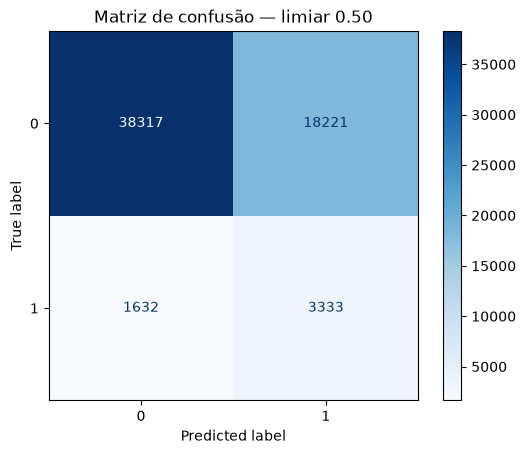

In [4]:
metrics = pd.Series({
    'ROC AUC': roc_auc_score(y_test, score),
    'Average Precision': average_precision_score(y_test, score),
    'Limiar': threshold,
})
display(metrics.to_frame('valor'))
print(classification_report(y_test, prediction, digits=4))
ConfusionMatrixDisplay.from_predictions(y_test, prediction, cmap='Blues')
plt.title(f'Matriz de confusão — limiar {threshold:.2f}')
plt.show()

## 4. Curvas ROC e Precisão–Recall

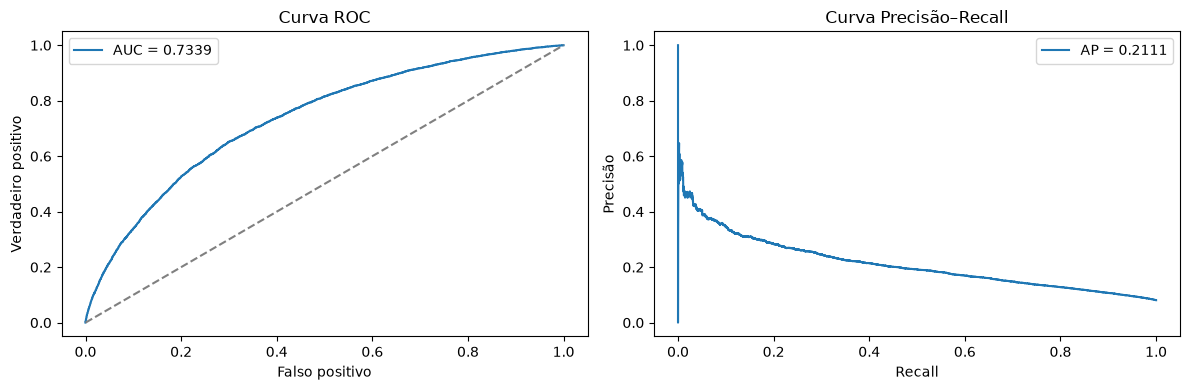

In [5]:
fpr, tpr, _ = roc_curve(y_test, score)
precision, recall, _ = precision_recall_curve(y_test, score)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, label=f"AUC = {metrics['ROC AUC']:.4f}")
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(xlabel='Falso positivo', ylabel='Verdadeiro positivo', title='Curva ROC')
axes[0].legend()
axes[1].plot(recall, precision, label=f"AP = {metrics['Average Precision']:.4f}")
axes[1].set(xlabel='Recall', ylabel='Precisão', title='Curva Precisão–Recall')
axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Interpretabilidade

Os coeficientes representam associação com o score, não causalidade. Coeficientes positivos elevam o risco estimado; negativos reduzem.

,feature,coefficient,absolute_coefficient
18,numeric__amt_goods_price,-1.166470,1.166470
16,numeric__amt_credit,1.076281,1.076281
93,categorical__name_education_type_Academic degree,-0.827638,0.827638
89,categorical__name_income_type_Other_low_freq,0.570907,0.570907
84,categorical__organization_type_Transport: type 3,0.497477,0.497477
90,categorical__name_income_type_Pensioner,-0.493746,0.493746
67,categorical__organization_type_Military,-0.470222,0.470222
79,categorical__organization_type_Trade: type 2,-0.466488,0.466488
96,categorical__name_education_type_Lower secondary,0.440473,0.440473
0,numeric__ext_source_2,-0.412137,0.412137


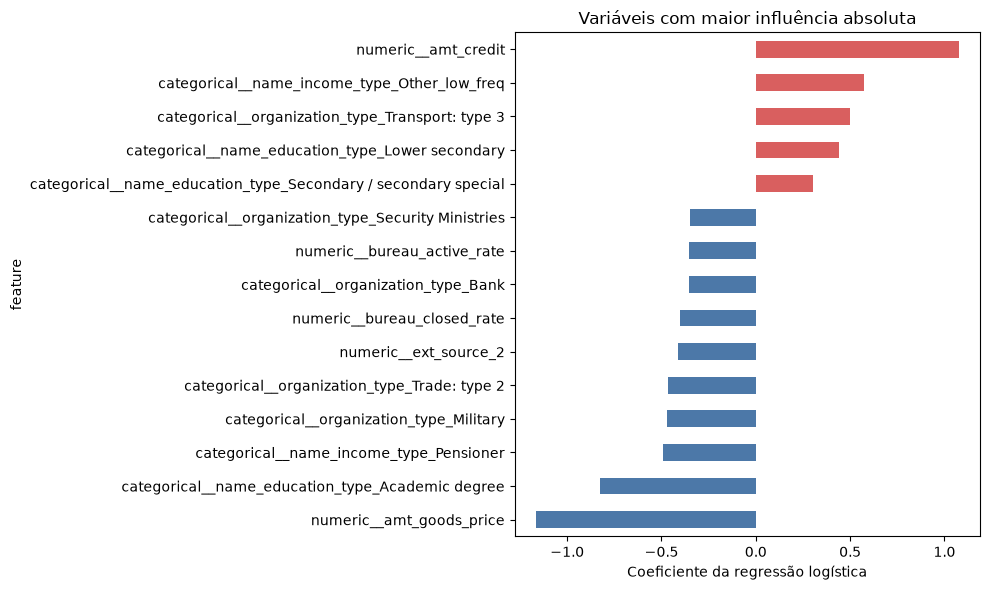

In [6]:
pipeline = artifact['model']
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coefficients = pipeline.named_steps['classifier'].coef_[0]
importance = (pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
              .assign(absolute_coefficient=lambda frame: frame['coefficient'].abs())
              .sort_values('absolute_coefficient', ascending=False))
display(importance.head(25))
top = importance.head(15).sort_values('coefficient')
colors = np.where(top['coefficient'] >= 0, '#d95f5f', '#4c78a8')
top.plot.barh(x='feature', y='coefficient', color=colors, legend=False, figsize=(10, 6))
plt.title('Variáveis com maior influência absoluta')
plt.xlabel('Coeficiente da regressão logística')
plt.tight_layout(); plt.show()

## 6. Conclusão

O ROC AUC mede a ordenação geral do risco. Average Precision e recall da classe inadimplente são essenciais devido ao desbalanceamento. O limiar de decisão deve ser calibrado com custos reais antes do uso em produção.